# Службен весник — SONAR re-scoring of the non-high-quality pairs

`01_2` wrote `pairs_filtered.parquet`: 369,325 rows, 43 columns. Every row with
`is_high_quality = False` was accepted by the matcher on weak evidence (a Hybrid score under
0.85) or on length alone (Gale-Church), and its `match_confidence` cannot say which, because it
mixes the two scales.

This notebook gives each of those rows one content score, **the SONAR similarity between its own
Macedonian and Albanian text**, and measures what that score is worth by also scoring *wrong*
pairs. **Nothing is dropped and no existing column changes.** Three columns are added:

| Column | Meaning |
|---|---|
| `sonar_cosine` | similarity of the row's mk and sq text. Empty on `is_high_quality` rows, which are not scored |
| `sonar_text_too_short` | the shorter of the two texts is under 20 characters |
| `ref_number_contradiction` | `True`: both sides carry reference numbers (`25-309/1`, `121/07`, `2024`) and none match, so almost certainly a wrong pair. `False`: at least one matches. Empty: one side has none, so it cannot tell |

| § | |
|---|---|
| 0 | Setup |
| 1 | Load the uploaded `pairs_filtered.parquet` |
| 2 | Encoder, and a 2k-row measurement: speed, fp32 vs fp16, long texts — **sets `PRECISION`** |
| 3 | Encode and score, in checkpointed shards on Drive |
| 4 | Assemble the three columns |
| 5 | Calibration: these rows vs wrong pairs |
| 6 | Cutoff options — nothing is applied |
| 7 | Write and download |

## Four things worth knowing

1. **The wrong-pairs test is the yardstick.** Unrelated gazette texts already score around 0.35,
   so a raw number means nothing on its own. Each row's Macedonian text is also scored against up
   to five Albanian texts taken from *other* rows of the same issue, of similar length. A cutoff is
   only worth something where these rows clearly outscore those.
2. **On Hybrid links the score is not new evidence.** The pair texts are the `clean_text` the
   matcher itself embedded, and `HybridMatcher` already weighted this cosine at 0.45 (ramped in
   between 25 and 80 characters). For Gale-Church links, which used length only, and for short
   headings, it is new.
3. **Short texts are scored like every other row**, and only flagged. The known weakness: SONAR
   reads the noun, not the number, so on `sl-2024-09` `Neni 1` scored 0.617 against `Листа на`
   but 0.574 against its real translation `Член 1`. §5 and §6 show the `<20` bin separately.
4. **fp16 was never compared with fp32 in this repo** (`scripts/parity_check.py` is fp32 only).
   §2 measures it on 2,000 rows before anything long runs.

---
## 0. Setup

**Colab: Runtime → Change runtime type → a GPU.** The first cell installs `transformers>=5.5`
and `sentencepiece`. Colab ships `transformers` 4.x, which pins `huggingface_hub<1.0`; the SONAR
port needs 5.5+. If the cell says to restart, do Runtime → Restart session and Run all again.

The model is `cointegrated/SONAR_200_text_encoder`, the same checkpoint and the same NLLB language
codes (`mkd_Cyrl`, `als_Latn`) the pipeline and the remote service use.

Checkpoints go to **Google Drive**: a disconnected runtime wipes `/content`, Drive survives it.
Outside Colab the notebook reads `_local/pairs_filtered.parquet` and checkpoints to
`_local/sonar_checkpoints/`.

In [1]:
import re
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules


def installed_version(package: str):
    """(major, minor) of an installed distribution, or None if it is not installed."""
    from importlib import metadata

    try:
        numbers = re.findall(r"\d+", metadata.version(package))
    except metadata.PackageNotFoundError:
        return None
    return tuple(int(n) for n in (numbers + ["0", "0"])[:2])


if IN_COLAB and (
    (installed_version("transformers") or (0, 0)) < (5, 5)
    or installed_version("sentencepiece") is None
):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "transformers>=5.5", "sentencepiece"],
        check=True,
    )
    if "transformers" in sys.modules:
        raise SystemExit("transformers was imported before the upgrade -- "
                         "Runtime -> Restart session, then Run all")

print("running in colab:", IN_COLAB, "| transformers", installed_version("transformers"))

running in colab: True | transformers (5, 16)


In [2]:
import hashlib
import json
import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 160)

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")

print("pandas", pd.__version__, "| pyarrow", pa.__version__)

Mounted at /content/drive
pandas 2.2.3 | pyarrow 23.0.1


### Configuration

`PRECISION` starts as `None` on purpose. Run §1–§2, read the measurement, set it to `"fp32"` or
`"fp16"` here, re-run this cell, then run §3 onward. §3 refuses to start while it is `None`.

In [3]:
# ---- where the data lives ---------------------------------------------------
DATA_DIR = Path("/content") if IN_COLAB else Path("_local")
INPUT_GLOB = "pairs_filtered*.parquet"     # Colab renames a re-upload to "pairs_filtered (1).parquet"
OUTPUT_PATH = DATA_DIR / "pairs_sonar.parquet"
EXPECTED_ROWS = 369_325                    # pairs_filtered.parquet as 01_2 §7 wrote it
EXPECTED_COLUMNS = 43

# ---- checkpoints: Drive, because a runtime recycle wipes /content ------------
CHECKPOINT_DIR = (Path("/content/drive/MyDrive/slv_sonar_rescoring") if IN_COLAB
                  else DATA_DIR / "sonar_checkpoints")
SHARD_ROWS = 10_000                        # whole issues are packed into shards of about this many rows

# ---- encoder: same checkpoint, codes and limits as remote_sonar/sonar_service.py
MODEL_NAME = "cointegrated/SONAR_200_text_encoder"
DIMENSIONS = 1024
LANG_MK = "mkd_Cyrl"
LANG_SQ = "als_Latn"                       # NLLB has no sqi_Latn, and a wrong code is silently ignored
MAX_TOKENS = 512                           # longer texts are truncated, as in the pipeline
BATCH_CAP = 64                             # rows per GPU batch
CHAR_BUDGET = 32_000                       # padded-size budget per batch (characters x rows)

# ---- set after reading §2 ----------------------------------------------------
#   "fp32" -> the precision scripts/parity_check.py measured (1.2e-07)
#   "fp16" -> faster; §2 reports how far it moves the scores
#   None   -> §3 refuses to run
PRECISION = "fp16"

# ---- §2 measurement -------------------------------------------------------------
SAMPLE_ROWS = 2_000
SEED = 20260915

# ---- the new columns ------------------------------------------------------------
SHORT_TEXT_CHARS = 20                      # sonar_text_too_short: shorter side under this
# scripts/eval_matching.py's "rich" numbers: separator-bearing (25-309/1, 121/07, 11.1.2024)
# or three digits and up. Bare 1-2 digit numbers repeat everywhere ("Член 2") and are ignored.
RICH = re.compile(r"\d+(?:[./\-]\d+)+|\d{3,}")

# ---- wrong-pairs test -----------------------------------------------------------
NULL_DRAWS = 5                             # wrong Albanian texts scored per row
NULL_LEN_RATIO = (0.8, 1.25)               # preferred length band, relative to the row's own sq text

# ---- reporting -------------------------------------------------------------------
LENGTH_BINS = [0, 20, 80, 300, np.inf]     # characters on the shorter side
LENGTH_LABELS = ["<20", "20-80", "80-300", "300+"]
CUTOFFS = [round(float(c), 2) for c in np.arange(0.40, 0.851, 0.05)]

### Chart styling

The same palette as `01` and `01_2`, so a colour means the same thing in every notebook. Here
slot 1 (blue) is always *these rows* and slot 2 (orange) is always *wrong pairs*.

In [4]:
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]   # categorical, fixed order
SEQ_BLUE = "#2a78d6"                                     # magnitude / single-series
SEQ_LIGHT = "#cde2fb"
INK = "#0b0b0b"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"
STATUS = {"good": "#0ca30c", "warning": "#fab219", "critical": "#d03b3b"}

plt.rcParams.update(
    {
        "figure.figsize": (11, 4.2),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.labelcolor": INK,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "text.color": INK,
        "legend.frameon": False,
        "lines.linewidth": 2.0,
        "font.size": 10,
    }
)


def thousands(ax, axis="y"):
    '''Format an axis with thousands separators.'''
    fmt = plt.FuncFormatter(lambda v, _: f"{v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)
    return ax

---
## 1. Load

Looks for `pairs_filtered*.parquet` in `DATA_DIR`, newest first; in Colab, if there is none, it
opens the upload dialog. Refuses a file that already has the SONAR columns (that would be
`pairs_sonar.parquet`), and checks `sq_component_id` is present and unique, because it is the key
that ties each checkpointed score back to its row.

`mk_text` and `sq_text` are read into local copies with nulls as `""`. The columns themselves are
never touched, and §7 checks that on the written file.

In [5]:
REQUIRED_COLUMNS = [
    "slv_identifier", "filename", "year", "sq_component_id", "mk_text", "sq_text",
    "match_confidence", "is_high_quality", "gale_church_inferred", "numeric_overlap_raw",
]
NEW_COLUMNS = ["sonar_cosine", "sonar_text_too_short", "ref_number_contradiction"]


def find_input() -> Path:
    """The pairs_filtered parquet to read -- already on disk, or uploaded now."""
    on_disk = sorted(DATA_DIR.glob(INPUT_GLOB), key=lambda p: p.stat().st_mtime, reverse=True)
    if on_disk:
        return on_disk[0]
    if not IN_COLAB:
        raise FileNotFoundError(f"no {INPUT_GLOB} in {DATA_DIR.resolve()}")

    from google.colab import files

    print(f"no {INPUT_GLOB} in {DATA_DIR} -- upload pairs_filtered.parquet")
    uploaded = [name for name in files.upload() if name.endswith(".parquet")]
    chosen = [name for name in uploaded if name.startswith("pairs_filtered")] or uploaded
    if len(chosen) != 1:
        raise RuntimeError(f"expected one pairs_filtered .parquet upload, got {uploaded}")
    return Path(chosen[0]).resolve()


input_path = find_input()
t0 = time.time()
df = pd.read_parquet(input_path)
input_columns = list(df.columns)

missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
assert not missing, f"{input_path.name} is missing {missing} -- is this 01_2's pairs_filtered.parquet?"
already = [c for c in NEW_COLUMNS if c in df.columns]
assert not already, f"{input_path.name} already has {already} -- upload pairs_filtered.parquet, not pairs_sonar"
if len(input_columns) != EXPECTED_COLUMNS:
    print(f"WARNING: {len(input_columns)} columns, but 01_2 wrote {EXPECTED_COLUMNS}")
if len(df) != EXPECTED_ROWS:
    print(f"WARNING: {len(df):,} rows, but 01_2 wrote {EXPECTED_ROWS:,} -- a subset or a different run")

assert df["is_high_quality"].notna().all(), "is_high_quality has nulls"
assert df["filename"].notna().all(), "filename has nulls -- the wrong-pairs test groups by issue"
assert df["sq_component_id"].notna().all(), "sq_component_id has nulls -- it is the row key"
assert df["sq_component_id"].is_unique, "sq_component_id repeats -- it is the row key"

mk_text = df["mk_text"].fillna("")
sq_text = df["sq_text"].fillna("")
shorter_side = np.minimum(mk_text.str.len().to_numpy(dtype=np.int64),
                          sq_text.str.len().to_numpy(dtype=np.int64))
length_bin = pd.Series(pd.cut(shorter_side, LENGTH_BINS, right=False, labels=LENGTH_LABELS),
                       index=df.index)
to_score = ~df["is_high_quality"].astype(bool)

print(f"read {input_path} in {time.time() - t0:,.1f}s")
print(f"{len(df):,} rows x {df.shape[1]} columns | {df['filename'].nunique():,} issues")
print(f"{int(to_score.sum()):,} rows to score (is_high_quality == False), "
      f"{int((~to_score).sum()):,} high-quality rows left unscored")
print(f"unique texts to encode: {mk_text[to_score].nunique():,} mk, {sq_text[to_score].nunique():,} sq")

read /content/pairs_filtered.parquet in 3.8s
369,325 rows x 43 columns | 2,486 issues
251,411 rows to score (is_high_quality == False), 117,914 high-quality rows left unscored
unique texts to encode: 195,084 mk, 229,035 sq


In [6]:
overview = pd.crosstab(
    length_bin[to_score].rename("shorter side (chars)"),
    df.loc[to_score, "gale_church_inferred"].astype(bool)
      .map({True: "gale_church_inferred", False: "other non-HQ"}),
    margins=True,
    margins_name="total",
)
overview

gale_church_inferred,gale_church_inferred,other non-HQ,total
shorter side (chars),,,
<20,7601,25389,32990
20-80,11276,49338,60614
80-300,22989,114496,137485
300+,2542,17780,20322
total,44408,207003,251411


---
## 2. The encoder, and what it costs

A copy of `remote_sonar/sonar_service.py`'s `_Sonar.encode`, not of the pipeline's
`SonarEncoder.encode`. The difference matters only under fp16: the service averages the token
vectors in **float32** after a half-precision forward pass, because a masked mean over a long
sequence loses too much in fp16. Batches are sorted by length and closed on a padded-size budget,
also as in the service.

`count_tokens` runs the tokenizer without truncation, so a text longer than 512 tokens can be
counted even though the model only sees its first 512.

In [7]:
_TOKENIZER = None
_MODELS = {}  # precision -> model; at most one on the device at a time


def device_name() -> str:
    import torch

    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def tokenizer():
    global _TOKENIZER
    if _TOKENIZER is None:
        import transformers
        from transformers import AutoTokenizer

        transformers.logging.set_verbosity_error()  # the no-truncation count warns on every long text
        _TOKENIZER = AutoTokenizer.from_pretrained(MODEL_NAME)
        for code in (LANG_MK, LANG_SQ):
            # The tokenizer ignores an unknown language code instead of raising.
            assert _TOKENIZER.convert_tokens_to_ids(code) != _TOKENIZER.unk_token_id, \
                f"{code} is not a language token of {MODEL_NAME}"
    return _TOKENIZER


def unload() -> None:
    import gc

    _MODELS.clear()
    gc.collect()
    try:
        import torch

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except ImportError:
        pass


def model(precision: str):
    if precision not in ("fp32", "fp16"):
        raise ValueError(f"precision must be 'fp32' or 'fp16', got {precision!r}")
    if precision in _MODELS:
        return _MODELS[precision]
    from transformers.models.m2m_100.modeling_m2m_100 import M2M100Encoder

    device = device_name()
    if precision == "fp16" and device != "cuda":
        raise RuntimeError("fp16 is only supported here on a CUDA GPU")
    unload()
    encoder = M2M100Encoder.from_pretrained(MODEL_NAME)
    if precision == "fp16":
        encoder = encoder.half()
    encoder = encoder.to(device).eval()
    assert int(encoder.config.d_model) == DIMENSIONS, "not the SONAR text space"
    _MODELS[precision] = encoder
    return encoder


def length_batches(texts: list) -> list:
    """Indices grouped by length, closed on a padded-size budget (sonar_service._Sonar._batches)."""
    order = sorted(range(len(texts)), key=lambda i: len(texts[i]))
    batches, current, widest = [], [], 0
    for i in order:
        width = max(widest, len(texts[i]) or 1)
        if current and (len(current) + 1 > BATCH_CAP or width * (len(current) + 1) > CHAR_BUDGET):
            batches.append(current)
            current, widest = [i], len(texts[i]) or 1
        else:
            current.append(i)
            widest = width
    if current:
        batches.append(current)
    return batches


def encode_texts(texts: list, lang_code: str, precision: str) -> np.ndarray:
    """(len(texts), 1024) float32, rows unit-norm, in input order. One language per call."""
    import torch

    out = np.zeros((len(texts), DIMENSIONS), dtype=np.float32)
    if not texts:
        return out
    tok = tokenizer()
    encoder = model(precision)
    device = next(encoder.parameters()).device
    tok.src_lang = lang_code  # tokenizer state: never mix languages in one call
    for indices in length_batches(texts):
        chunk = [texts[i] or " " for i in indices]
        with torch.inference_mode():
            batch = tok(chunk, return_tensors="pt", padding=True, truncation=True,
                        max_length=MAX_TOKENS).to(device)
            hidden = encoder(**batch).last_hidden_state.float()
            mask = batch["attention_mask"].unsqueeze(-1).float()
            pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
            pooled = torch.nn.functional.normalize(pooled, dim=1)
        out[indices] = pooled.cpu().numpy()
    return out


def count_tokens(texts: list, lang_code: str) -> np.ndarray:
    """Tokens each text has *before* truncation, special tokens included."""
    tok = tokenizer()
    tok.src_lang = lang_code
    counts = np.zeros(len(texts), dtype=np.int32)
    for start in range(0, len(texts), 4096):
        ids = tok([t or " " for t in texts[start:start + 4096]], truncation=False)["input_ids"]
        counts[start:start + len(ids)] = [len(row) for row in ids]
    return counts


def synchronized_clock() -> float:
    import torch

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

### Measure on 2,000 rows

A random sample of the rows to score. Its unique texts are encoded in fp32 and, on a CUDA GPU, in
fp16. For each precision:

* **speed**: rows and characters per second, and the full run projected from characters per
  second (encoding time grows with text length, so characters project better than rows);
* **drift**: how far fp16 moves the vectors (the same measure `parity_check.py` reports, where
  fp32 gave 1.2e-07) and how far it moves each row's score.

Then set `PRECISION` in the config cell.

In [8]:
sample = df.loc[to_score].sample(n=min(SAMPLE_ROWS, int(to_score.sum())), random_state=SEED)
sample_mk_text = sample["mk_text"].fillna("")
sample_sq_text = sample["sq_text"].fillna("")
sample_mk = list(pd.unique(sample_mk_text))
sample_sq = list(pd.unique(sample_sq_text))
sample_chars = sum(map(len, sample_mk)) + sum(map(len, sample_sq))
full_chars = int(pd.Series(pd.unique(mk_text[to_score])).str.len().sum()
                 + pd.Series(pd.unique(sq_text[to_score])).str.len().sum())
mk_position = pd.Index(sample_mk).get_indexer(sample_mk_text)
sq_position = pd.Index(sample_sq).get_indexer(sample_sq_text)

precisions = ["fp32", "fp16"] if device_name() == "cuda" else ["fp32"]
print("device:", device_name(), "| measuring", precisions)

measured, vectors, sample_cosine = {}, {}, {}
for precision in precisions:
    model(precision)
    encode_texts(["Службен весник", "Gazeta zyrtare"], LANG_MK, precision)  # warm-up
    started = synchronized_clock()
    mk_vectors = encode_texts(sample_mk, LANG_MK, precision)
    sq_vectors = encode_texts(sample_sq, LANG_SQ, precision)
    elapsed = synchronized_clock() - started
    vectors[precision] = (mk_vectors, sq_vectors)
    sample_cosine[precision] = np.einsum("ij,ij->i", mk_vectors[mk_position], sq_vectors[sq_position])
    chars_per_second = sample_chars / elapsed
    measured[precision] = {
        "sample_rows": len(sample),
        "unique_texts": len(sample_mk) + len(sample_sq),
        "seconds": round(elapsed, 1),
        "rows_per_second": round(len(sample) / elapsed, 1),
        "chars_per_second": round(chars_per_second),
        "projected_full_run_minutes": round(full_chars / chars_per_second / 60, 1),
    }
unload()

sample_tokens = np.concatenate([count_tokens(sample_mk, LANG_MK), count_tokens(sample_sq, LANG_SQ)])
print(f"texts longer than {MAX_TOKENS} tokens in the sample: "
      f"{int((sample_tokens > MAX_TOKENS).sum()):,} of {len(sample_tokens):,} "
      f"({(sample_tokens > MAX_TOKENS).mean():.2%})")

if "fp16" in vectors:
    vector_distance = np.concatenate([
        1.0 - np.einsum("ij,ij->i", vectors["fp32"][side], vectors["fp16"][side]) for side in (0, 1)
    ])
    score_shift = np.abs(sample_cosine["fp16"] - sample_cosine["fp32"])
    print(f"fp16 vs fp32 vector cosine distance: max {vector_distance.max():.2e}, "
          f"median {np.median(vector_distance):.2e}")
    print(f"fp16 vs fp32 row score shift: max {score_shift.max():.4f}, "
          f"99th percentile {np.quantile(score_shift, 0.99):.4f}")

print("\nset PRECISION in the config cell, re-run it, then run §3 onward")
pd.DataFrame(measured).T

device: cuda | measuring ['fp32', 'fp16']


config.json:   0%|          | 0.00/812 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.06GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/387 [00:00<?, ?it/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/4.23k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/387 [00:00<?, ?it/s]

texts longer than 512 tokens in the sample: 4 of 3,925 (0.10%)
fp16 vs fp32 vector cosine distance: max 3.11e-05, median 9.54e-07
fp16 vs fp32 row score shift: max 0.0010, 99th percentile 0.0006

set PRECISION in the config cell, re-run it, then run §3 onward


,sample_rows,unique_texts,seconds,rows_per_second,chars_per_second,projected_full_run_minutes
fp32,2000.0,3925.0,90.6,22.1,6853.0,169.3
fp16,2000.0,3925.0,16.5,121.0,37566.0,30.9


---
## 3. Encode and score, in checkpointed shards

The rows to score are sorted by issue, and whole issues are packed into shards of about
`SHARD_ROWS` rows, so the wrong-pairs draw for an issue always finds all of that issue's rows in
one shard. Each shard is encoded, scored and written to `CHECKPOINT_DIR` before the next starts.
**A re-run skips every shard already on disk**, so a disconnect costs at most the shard in progress.

`manifest.json` records a fingerprint of the run: the row ids, model, precision, token limit and
wrong-pairs settings. If any of those change, this cell refuses to continue on the old shards
instead of mixing two runs.

### The wrong-pairs draw

For each row, up to `NULL_DRAWS` Albanian texts from other rows **of the same issue**:

* never the row's own Albanian text, nor an identical one (same text after casefolding and
  collapsing punctuation);
* never from a row with the same Macedonian text, whose Albanian side may well be a correct
  translation of this row's;
* preferably of similar length (0.8–1.25 × the row's own). If too few are in that band, it is
  topped up with the nearest lengths outside it.

These scores cost no extra encoding; the vectors are already there. They are kept in the
checkpoint for §5 and §6, not written as a column.

In [8]:
if PRECISION not in ("fp32", "fp16"):
    raise RuntimeError("set PRECISION to 'fp32' or 'fp16' in the config cell after reading §2, "
                       "re-run that cell, then run this one")

work = (
    pd.DataFrame({
        "sq_component_id": df.loc[to_score, "sq_component_id"],
        "filename": df.loc[to_score, "filename"],
        "mk_text": mk_text[to_score],
        "sq_text": sq_text[to_score],
    })
    .sort_values(["filename", "sq_component_id"], kind="stable")
    .reset_index(drop=True)
)

shard_of_issue, shard, filled = {}, 0, 0
for filename, rows in work.groupby("filename", sort=False).size().items():
    if filled and filled + rows > SHARD_ROWS:
        shard, filled = shard + 1, 0
    shard_of_issue[filename] = shard
    filled += rows
work["shard"] = work["filename"].map(shard_of_issue).astype(int)
n_shards = int(work["shard"].max()) + 1

run_settings = {
    "model": MODEL_NAME, "precision": PRECISION, "max_tokens": MAX_TOKENS,
    "lang_codes": [LANG_MK, LANG_SQ], "null_draws": NULL_DRAWS,
    "null_len_ratio": list(NULL_LEN_RATIO), "seed": SEED, "shard_rows": SHARD_ROWS,
}
fingerprint = hashlib.sha256(
    (json.dumps(run_settings, sort_keys=True) + "\n" + "\n".join(work["sq_component_id"])).encode()
).hexdigest()


def shard_path(index: int) -> Path:
    return CHECKPOINT_DIR / f"shard_{index:04d}.parquet"


CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
manifest_path = CHECKPOINT_DIR / "manifest.json"
if manifest_path.exists():
    stored = json.loads(manifest_path.read_text())
    if stored.get("fingerprint") != fingerprint:
        raise RuntimeError(
            f"{CHECKPOINT_DIR} holds shards from a different run (rows, model, precision, token "
            f"limit or wrong-pairs settings changed).\nstored:  {stored.get('settings')}\n"
            f"current: {run_settings}\nMove or delete that folder, or point CHECKPOINT_DIR "
            "elsewhere -- shards from two runs must not be mixed."
        )
else:
    manifest_path.write_text(json.dumps(
        {"fingerprint": fingerprint, "settings": run_settings, "shards": n_shards,
         "rows": len(work), "input": input_path.name}, indent=2))

on_disk = sum(shard_path(i).exists() for i in range(n_shards))
print(f"{len(work):,} rows in {n_shards} shards | {on_disk} already in {CHECKPOINT_DIR}")

251,411 rows in 26 shards | 1 already in /content/drive/MyDrive/slv_sonar_rescoring


In [9]:
def normalised_codes(texts: pd.Series) -> np.ndarray:
    """An integer per distinct text, after casefolding and collapsing punctuation."""
    normal = texts.str.casefold().str.replace(r"\W+", " ", regex=True).str.strip()
    return pd.factorize(normal)[0]


def draw_wrong_pairs(sq_length: np.ndarray, mk_code: np.ndarray, sq_code: np.ndarray,
                     rng: np.random.Generator) -> np.ndarray:
    """(n, NULL_DRAWS) positions within one issue whose sq text is a wrong pair for each row; -1 = none."""
    n = len(sq_length)
    picks = np.full((n, NULL_DRAWS), -1, dtype=np.int64)
    low, high = NULL_LEN_RATIO
    for i in range(n):
        eligible = np.flatnonzero((sq_code != sq_code[i]) & (mk_code != mk_code[i]))
        if eligible.size == 0:
            continue
        ratio = sq_length[eligible] / max(int(sq_length[i]), 1)
        in_band = (ratio >= low) & (ratio <= high)
        close = eligible[in_band]
        if close.size >= NULL_DRAWS:
            chosen = rng.choice(close, NULL_DRAWS, replace=False)
        else:
            rest = eligible[~in_band]
            nearest = rest[np.argsort(np.abs(sq_length[rest] - sq_length[i]), kind="stable")]
            chosen = np.concatenate([close, nearest[:NULL_DRAWS - close.size]])
        picks[i, :chosen.size] = chosen
    return picks


def score_shard(rows: pd.DataFrame, shard_index: int) -> pa.Table:
    rows = rows.reset_index(drop=True)
    mk_unique = list(pd.unique(rows["mk_text"]))
    sq_unique = list(pd.unique(rows["sq_text"]))
    mk_vectors = encode_texts(mk_unique, LANG_MK, PRECISION)
    sq_vectors = encode_texts(sq_unique, LANG_SQ, PRECISION)
    mk_row = pd.Index(mk_unique).get_indexer(rows["mk_text"])
    sq_row = pd.Index(sq_unique).get_indexer(rows["sq_text"])
    assert (mk_row >= 0).all() and (sq_row >= 0).all()

    own = np.einsum("ij,ij->i", mk_vectors[mk_row], sq_vectors[sq_row])

    mk_code = normalised_codes(rows["mk_text"])
    sq_code = normalised_codes(rows["sq_text"])
    sq_length = rows["sq_text"].str.len().to_numpy(dtype=np.int64)
    rng = np.random.default_rng([SEED, shard_index])
    wrong = np.full((len(rows), NULL_DRAWS), np.nan, dtype=np.float32)
    groups = rows.groupby("filename", sort=False).indices
    for filename in sorted(groups):
        positions = np.asarray(groups[filename])
        picks = draw_wrong_pairs(sq_length[positions], mk_code[positions], sq_code[positions], rng)
        valid = picks >= 0
        partners = positions[np.where(valid, picks, 0)]
        scores = np.einsum("id,ikd->ik", mk_vectors[mk_row[positions]], sq_vectors[sq_row[partners]])
        wrong[positions] = np.where(valid, scores, np.nan)

    return pa.table({
        "sq_component_id": pa.array(rows["sq_component_id"].to_numpy(dtype=object), pa.string()),
        "sonar_cosine": pa.array(own.astype(np.float32)),
        "wrong_pair_cosines": pa.FixedSizeListArray.from_arrays(
            pa.array(wrong.ravel(), type=pa.float32()), NULL_DRAWS),
        "mk_tokens": pa.array(count_tokens(mk_unique, LANG_MK)[mk_row]),
        "sq_tokens": pa.array(count_tokens(sq_unique, LANG_SQ)[sq_row]),
    })


def write_shard(table: pa.Table, path: Path) -> None:
    """Write-then-rename, so an interrupted write never leaves a shard that looks finished."""
    temporary = path.with_name(path.name + ".tmp")
    pq.write_table(table, temporary, compression="zstd")
    os.replace(temporary, path)

In [10]:
pending = [i for i in range(n_shards) if not shard_path(i).exists()]
rows_by_shard = work.groupby("shard").indices
rows_pending = sum(len(rows_by_shard[i]) for i in pending)
print(f"{n_shards - len(pending)} of {n_shards} shards done; {len(pending)} to go ({rows_pending:,} rows)")

started, rows_done = time.time(), 0
for number, shard in enumerate(pending, 1):
    rows = work.iloc[rows_by_shard[shard]]
    table = score_shard(rows, shard)
    assert table.num_rows == len(rows), f"shard {shard}: {table.num_rows} scores for {len(rows)} rows"
    write_shard(table, shard_path(shard))
    rows_done += len(rows)
    elapsed = time.time() - started
    remaining = elapsed / rows_done * (rows_pending - rows_done)
    print(f"shard {shard:4d} ({number}/{len(pending)}) {len(rows):7,} rows | "
          f"{elapsed / 60:6.1f} min elapsed | ~{remaining / 60:6.1f} min left", flush=True)
unload()
print("all shards on disk")

1 of 26 shards done; 25 to go (242,272 rows)


config.json:   0%|          | 0.00/812 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.9k [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 4.85MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

...

special_tokens_map.json:   0%|          | 0.00/4.23k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.06GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/387 [00:00<?, ?it/s]

shard    1 (1/25)   9,968 rows |    2.8 min elapsed | ~  64.9 min left
shard    2 (2/25)   9,930 rows |    4.1 min elapsed | ~  46.3 min left
shard    3 (3/25)   9,392 rows |    5.5 min elapsed | ~  39.8 min left
shard    4 (4/25)   9,879 rows |    6.9 min elapsed | ~  36.0 min left
shard    5 (5/25)   9,447 rows |    8.3 min elapsed | ~  33.0 min left
shard    6 (6/25)   9,881 rows |    9.9 min elapsed | ~  31.1 min left
shard    7 (7/25)   9,959 rows |   11.4 min elapsed | ~  28.9 min left
shard    8 (8/25)   9,809 rows |   12.9 min elapsed | ~  27.1 min left
shard    9 (9/25)   9,924 rows |   14.3 min elapsed | ~  24.9 min left
shard   10 (10/25)   9,787 rows |   15.7 min elapsed | ~  23.1 min left
shard   11 (11/25)   9,962 rows |   17.2 min elapsed | ~  21.4 min left
shard   12 (12/25)   9,767 rows |   18.8 min elapsed | ~  19.9 min left
shard   13 (13/25)   9,949 rows |   20.4 min elapsed | ~  18.3 min left
shard   14 (14/25)   9,689 rows |   21.9 min elapsed | ~  16.7 min left
s

---
## 4. Assemble the three columns

Reads every shard back and checks each row to score appears **exactly once**, then maps the
scores onto the frame by `sq_component_id`, so row order is untouched.

* `sonar_cosine` is filled on the scored rows and empty on every `is_high_quality` row.
* `sonar_text_too_short` and `ref_number_contradiction` depend on the text only, so they are
  computed for **every** row, high quality included.

`ref_number_contradiction` uses `scripts/eval_matching.py`'s rule unchanged. One consequence of
keeping it unchanged: a date written differently on the two sides (`11.01.2024` vs `11.1.2024`)
is two different tokens, so a pair whose *only* strong numbers are such a date counts as a
contradiction.

In [11]:
def rich_tokens(text: str) -> frozenset:
    return frozenset(RICH.findall(text))


def ref_number_contradiction(mk: pd.Series, sq: pd.Series) -> pd.arrays.BooleanArray:
    """True: both sides have strong numbers and none are shared. False: one is shared. NA: can't tell."""
    verdicts = []
    for left, right in zip(mk, sq):
        a, b = rich_tokens(left), rich_tokens(right)
        verdicts.append(pd.NA if not a or not b else not (a & b))
    return pd.array(verdicts, dtype="boolean")


_check = ref_number_contradiction(
    pd.Series(["Бр. 25-309/1 од 2024", "Бр. 25-309/1", "Член 2", "Одлука 121/07"]),
    pd.Series(["Nr. 25-309/1 2024", "Nr. 12/2020", "Neni 2", "Vendim"]),
)
assert _check[0] == False and _check[1] == True and _check[2] is pd.NA and _check[3] is pd.NA
del _check

In [12]:
missing_shards = [i for i in range(n_shards) if not shard_path(i).exists()]
assert not missing_shards, f"shards not written yet: {missing_shards[:10]} -- re-run §3"

scores = pa.concat_tables([pq.read_table(shard_path(i)) for i in range(n_shards)])
score_ids = scores.column("sq_component_id").to_pandas()
assert len(score_ids) == len(work), f"{len(score_ids):,} scores for {len(work):,} rows"
assert score_ids.is_unique, "a row was scored twice"
assert set(score_ids) == set(work["sq_component_id"]), "scored ids differ from the rows to score"

score_index = pd.Index(score_ids.to_numpy(dtype=object), name="sq_component_id")
cosine_by_id = pd.Series(scores.column("sonar_cosine").to_numpy(), index=score_index)
wrong_matrix = (scores.column("wrong_pair_cosines").combine_chunks().flatten()
                .to_numpy(zero_copy_only=False).reshape(-1, NULL_DRAWS))
tokens = pd.DataFrame({"mk_tokens": scores.column("mk_tokens").to_numpy(),
                       "sq_tokens": scores.column("sq_tokens").to_numpy()}, index=score_index)

df["sonar_cosine"] = df["sq_component_id"].map(cosine_by_id).astype("float64")
df["sonar_text_too_short"] = shorter_side < SHORT_TEXT_CHARS
df["ref_number_contradiction"] = ref_number_contradiction(mk_text, sq_text)

assert df.loc[to_score, "sonar_cosine"].notna().all(), "a row to score has no score"
assert df.loc[~to_score, "sonar_cosine"].isna().all(), "a high-quality row got a score"
assert list(df.columns) == input_columns + NEW_COLUMNS

truncated = (tokens["mk_tokens"] > MAX_TOKENS) | (tokens["sq_tokens"] > MAX_TOKENS)
verdict = df["ref_number_contradiction"]
print(f"sonar_cosine             {int(df['sonar_cosine'].notna().sum()):>9,} rows scored")
print(f"sonar_text_too_short     {int(df['sonar_text_too_short'].sum()):>9,} rows "
      f"({int(df.loc[to_score, 'sonar_text_too_short'].sum()):,} of them scored)")
print(f"ref_number_contradiction {int((verdict == True).sum()):>9,} True | "
      f"{int((verdict == False).sum()):,} False | {int(verdict.isna().sum()):,} can't tell")
print(f"truncated at {MAX_TOKENS} tokens  {int(truncated.sum()):>9,} scored rows "
      f"({truncated.mean():.2%}) -- SONAR saw only the first {MAX_TOKENS} tokens of a side")

sonar_cosine               251,411 rows scored
sonar_text_too_short        40,098 rows (32,990 of them scored)
ref_number_contradiction     7,612 True | 69,497 False | 292,216 can't tell
truncated at 512 tokens        377 scored rows (0.15%) -- SONAR saw only the first 512 tokens of a side


---
## 5. Calibration: these rows vs wrong pairs

Blue is the score of the rows being judged; orange is the score of wrong pairs drawn from the same
issues. The rows are not all correct, which is the point of the exercise, so blue is a *mixture*:
its right-hand mass sits above orange, and whatever overlaps orange is indistinguishable from a
wrong pair by this score.

`separation` is the chance that a row scores higher than a wrong pair from its own group:
0.5 = no information, 1.0 = perfectly apart. `rows_above_wrong_p95` is the share of rows scoring
higher than 95% of the wrong pairs.

183 rows had no other row in their issue to draw a wrong pair from


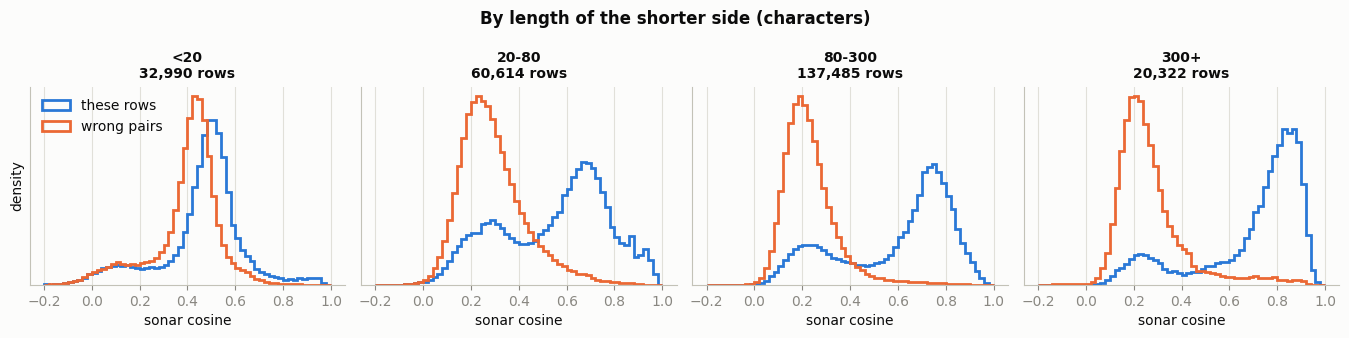

,rows,wrong_pairs,median_rows,median_wrong,wrong_p95,rows_above_wrong_p95,separation
group,,,,,,,
<20,32990,163460,0.487,0.423,0.579,0.163,0.662
20-80,60614,301970,0.598,0.269,0.556,0.562,0.811
80-300,137485,686209,0.682,0.211,0.431,0.730,0.880
300+,20322,101418,0.781,0.236,0.590,0.776,0.906


In [13]:
overlap = df.loc[to_score, "numeric_overlap_raw"].to_numpy(dtype=float)
scored = pd.DataFrame(
    {
        "sonar_cosine": df.loc[to_score, "sonar_cosine"].to_numpy(),
        "length_bin": np.asarray(length_bin[to_score], dtype=object),
        "gale_church_inferred": df.loc[to_score, "gale_church_inferred"].astype(bool).to_numpy(),
        "numbers": np.where(np.isnan(overlap), "no numerals either side",
                            np.where(overlap == 0, "numerals, none shared", "some numerals shared")),
        "contradiction": df.loc[to_score, "ref_number_contradiction"].array,
    },
    index=pd.Index(df.loc[to_score, "sq_component_id"].to_numpy(dtype=object), name="sq_component_id"),
)
wrong_pairs = pd.DataFrame(wrong_matrix, index=score_index).reindex(scored.index)
no_wrong_pair = int(wrong_pairs.isna().all(axis=1).sum())
print(f"{no_wrong_pair:,} rows had no other row in their issue to draw a wrong pair from")

HIST_BINS = np.linspace(-0.2, 1.0, 61)


def separation(real: np.ndarray, wrong: np.ndarray) -> float:
    """P(a row outscores a wrong pair), from ranks; 0.5 means no information."""
    if len(real) == 0 or len(wrong) == 0:
        return np.nan
    ranks = pd.Series(np.concatenate([real, wrong])).rank().to_numpy()
    return float((ranks[:len(real)].sum() - len(real) * (len(real) + 1) / 2) / (len(real) * len(wrong)))


def group_values(mask: pd.Series):
    real = scored.loc[mask, "sonar_cosine"].to_numpy()
    wrong = wrong_pairs.loc[mask].to_numpy().ravel()
    return real, wrong[~np.isnan(wrong)]


def separation_table(groups: list) -> pd.DataFrame:
    records = []
    for label, mask in groups:
        real, wrong = group_values(mask)
        wrong_p95 = float(np.quantile(wrong, 0.95)) if len(wrong) else np.nan
        records.append({
            "group": label,
            "rows": len(real),
            "wrong_pairs": len(wrong),
            "median_rows": float(np.median(real)) if len(real) else np.nan,
            "median_wrong": float(np.median(wrong)) if len(wrong) else np.nan,
            "wrong_p95": wrong_p95,
            "rows_above_wrong_p95": float((real > wrong_p95).mean()) if len(real) and len(wrong) else np.nan,
            "separation": separation(real, wrong),
        })
    return pd.DataFrame(records).set_index("group").round(3)


def plot_distributions(groups: list, title: str) -> None:
    fig, axes = plt.subplots(1, len(groups), figsize=(3.1 * len(groups) + 1.2, 3.4), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (label, mask) in zip(axes, groups):
        real, wrong = group_values(mask)
        if len(real):
            ax.hist(np.clip(real, HIST_BINS[0], HIST_BINS[-1]), bins=HIST_BINS, density=True,
                    histtype="step", linewidth=2, color=SERIES[0], label="these rows")
        if len(wrong):
            ax.hist(np.clip(wrong, HIST_BINS[0], HIST_BINS[-1]), bins=HIST_BINS, density=True,
                    histtype="step", linewidth=2, color=SERIES[1], label="wrong pairs")
        ax.set_title(f"{label}\n{len(real):,} rows", fontsize=10)
        ax.set_xlabel("sonar cosine")
        ax.set_yticks([])
        ax.grid(axis="y", visible=False)
    axes[0].set_ylabel("density")
    axes[0].legend(loc="upper left")
    fig.suptitle(title, fontweight="bold", color=INK)
    plt.tight_layout()
    plt.show()


by_length = [(label, scored["length_bin"] == label) for label in LENGTH_LABELS]
plot_distributions(by_length, "By length of the shorter side (characters)")
separation_table(by_length)

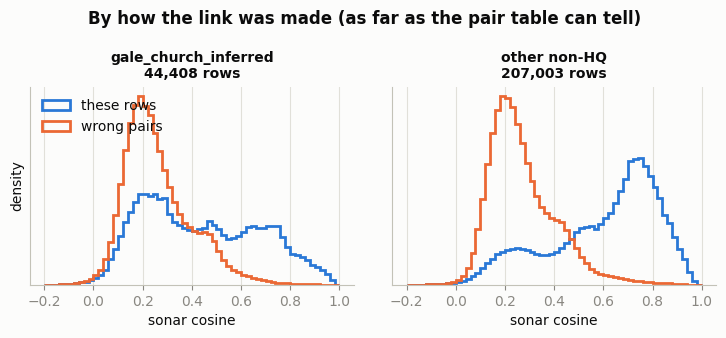

,rows,wrong_pairs,median_rows,median_wrong,wrong_p95,rows_above_wrong_p95,separation
group,,,,,,,
gale_church_inferred,44408,220586,0.409,0.233,0.519,0.372,0.718
other non-HQ,207003,1032471,0.663,0.242,0.522,0.686,0.874


In [14]:
by_method = [
    ("gale_church_inferred", scored["gale_church_inferred"]),
    ("other non-HQ", ~scored["gale_church_inferred"]),
]
plot_distributions(by_method, "By how the link was made (as far as the pair table can tell)")
separation_table(by_method)

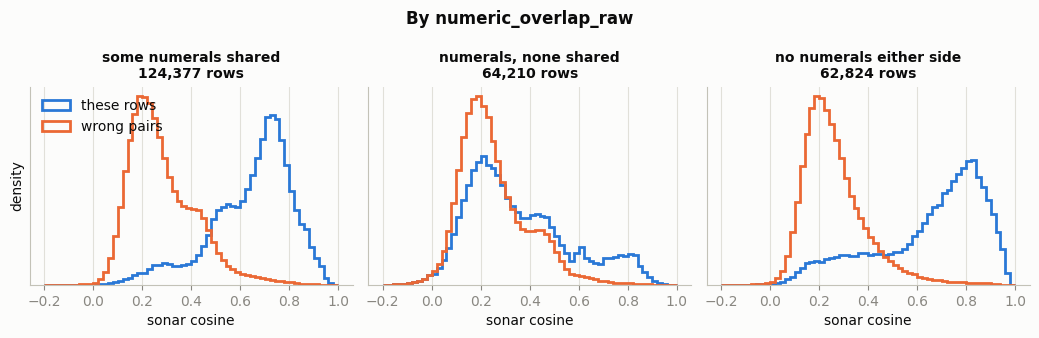

,rows,wrong_pairs,median_rows,median_wrong,wrong_p95,rows_above_wrong_p95,separation
group,,,,,,,
some numerals shared,124377,620976,0.683,0.252,0.533,0.777,0.935
"numerals, none shared",64210,318905,0.304,0.223,0.510,0.211,0.640
no numerals either side,62824,313176,0.715,0.237,0.513,0.752,0.905


In [15]:
by_numbers = [(label, scored["numbers"] == label)
              for label in ["some numerals shared", "numerals, none shared", "no numerals either side"]]
plot_distributions(by_numbers, "By numeric_overlap_raw")
separation_table(by_numbers)

### Does a low score coincide with contradicting reference numbers?

Only rows where both sides carry strong numbers have a verdict. If the score is informative, the
contradiction rate should fall as the score rises.

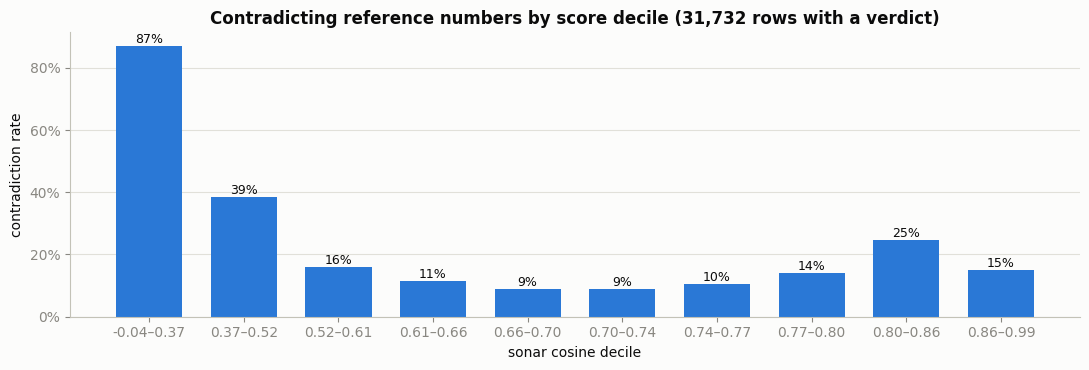

,rows,contradiction_rate
sonar_cosine,,
"(-0.0371, 0.369]",3174,0.871
"(0.369, 0.521]",3173,0.386
"(0.521, 0.606]",3173,0.160
"(0.606, 0.663]",3173,0.114
"(0.663, 0.703]",3173,0.090
"(0.703, 0.736]",3173,0.088
"(0.736, 0.767]",3173,0.104
"(0.767, 0.804]",3173,0.142
"(0.804, 0.86]",3173,0.247


In [16]:
checkable = scored[scored["contradiction"].notna()]
if len(checkable) >= 10:
    decile = pd.qcut(checkable["sonar_cosine"], 10, duplicates="drop")
    by_decile = (checkable.assign(contradiction=checkable["contradiction"].astype(bool))
                 .groupby(decile, observed=True)["contradiction"]
                 .agg(rows="size", contradiction_rate="mean"))
    labels = [f"{interval.left:.2f}–{interval.right:.2f}" for interval in by_decile.index]

    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.bar(labels, by_decile["contradiction_rate"], color=SEQ_BLUE, width=0.7)
    for x, value in enumerate(by_decile["contradiction_rate"]):
        ax.text(x, value, f"{value:.0%}", ha="center", va="bottom", fontsize=9, color=INK)
    ax.set_title(f"Contradicting reference numbers by score decile ({len(checkable):,} rows with a verdict)")
    ax.set_xlabel("sonar cosine decile")
    ax.set_ylabel("contradiction rate")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.grid(axis="x", visible=False)
    plt.tight_layout()
    plt.show()
    display_decile = by_decile.assign(contradiction_rate=by_decile["contradiction_rate"].round(3))
else:
    display_decile = pd.DataFrame()
    print(f"only {len(checkable)} rows have a reference-number verdict -- too few for deciles")
display_decile

---
## 6. Cutoff options

For each candidate cutoff, what keeping `sonar_cosine >= cutoff` would do to the scored rows.
**Nothing is applied here**; high-quality rows are not part of this table and would be kept anyway.

| Column | |
|---|---|
| `rows_kept`, `share_kept` | scored rows at or above the cutoff |
| `gale_church_kept` | of those, rows `01` inferred as Gale-Church links |
| `wrong_pairs_passing` | share of wrong pairs that would also pass: roughly, how often a wrong link gets through |
| `contradiction_kept` / `contradiction_dropped` | contradiction rate among kept / dropped rows that have a verdict |

The second table splits rows kept and wrong pairs passing by length bin. A cutoff that looks
safe overall can let most short wrong pairs through.

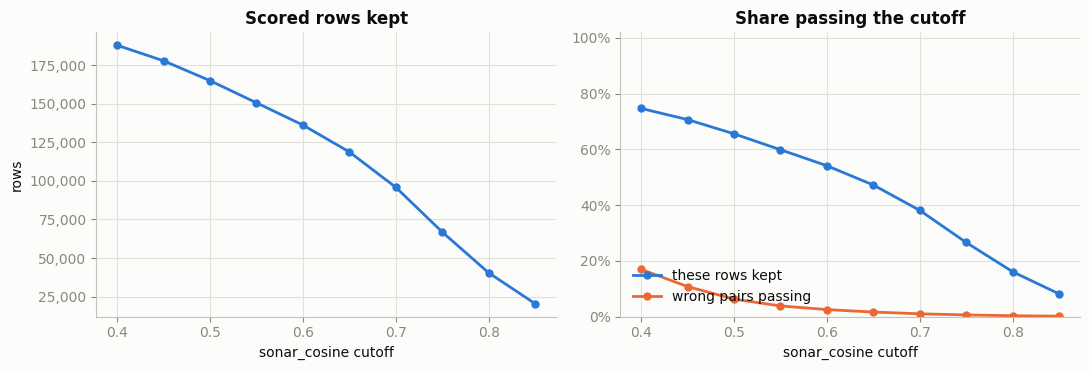

,rows_kept,share_kept,gale_church_kept,wrong_pairs_passing,contradiction_kept,contradiction_dropped
cutoff,,,,,,
0.40,187795,0.747,22663,0.169,0.158,0.836
0.45,177714,0.707,20204,0.108,0.149,0.760
0.50,164875,0.656,17465,0.063,0.140,0.671
0.55,150526,0.599,15150,0.038,0.134,0.574
0.60,136101,0.541,13031,0.025,0.133,0.482
0.65,118698,0.472,10559,0.016,0.136,0.402
0.70,95822,0.381,7960,0.010,0.145,0.328
0.75,66842,0.266,5284,0.006,0.170,0.271
0.80,40432,0.161,3247,0.003,0.198,0.245


In [17]:
wrong_values = wrong_pairs.to_numpy()
wrong_valid = ~np.isnan(wrong_values)
row_bin = scored["length_bin"].to_numpy()
gale_church = scored["gale_church_inferred"].to_numpy()
has_verdict = scored["contradiction"].notna().to_numpy()
contradicts = scored["contradiction"].to_numpy(dtype=bool, na_value=False)
cosine_values = scored["sonar_cosine"].to_numpy()


def rate(numerator: np.ndarray, denominator: np.ndarray) -> float:
    return float(numerator.sum() / denominator.sum()) if denominator.sum() else np.nan


records, per_bin = [], []
for cutoff in CUTOFFS:
    kept = cosine_values >= cutoff
    passing = (wrong_values >= cutoff) & wrong_valid
    records.append({
        "cutoff": cutoff,
        "rows_kept": int(kept.sum()),
        "share_kept": float(kept.mean()) if len(kept) else np.nan,
        "gale_church_kept": int((kept & gale_church).sum()),
        "wrong_pairs_passing": rate(passing, wrong_valid),
        "contradiction_kept": rate(contradicts & kept & has_verdict, kept & has_verdict),
        "contradiction_dropped": rate(contradicts & ~kept & has_verdict, ~kept & has_verdict),
    })
    for label in LENGTH_LABELS:
        in_bin = row_bin == label
        per_bin.append({
            "cutoff": cutoff,
            "length": label,
            "rows_kept": int((kept & in_bin).sum()),
            "wrong_pairs_passing": rate(passing[in_bin], wrong_valid[in_bin]),
        })

cutoff_table = pd.DataFrame(records).set_index("cutoff")
cutoff_by_length = (pd.DataFrame(per_bin)
                    .pivot(index="cutoff", columns="length", values=["rows_kept", "wrong_pairs_passing"])
                    .reindex(columns=LENGTH_LABELS, level="length"))

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))
left.plot(CUTOFFS, cutoff_table["rows_kept"], color=SERIES[0], marker="o", markersize=5)
left.set_title("Scored rows kept")
left.set_xlabel("sonar_cosine cutoff")
left.set_ylabel("rows")
thousands(left)
right.plot(CUTOFFS, cutoff_table["share_kept"], color=SERIES[0], marker="o", markersize=5,
           label="these rows kept")
right.plot(CUTOFFS, cutoff_table["wrong_pairs_passing"], color=SERIES[1], marker="o", markersize=5,
           label="wrong pairs passing")
right.set_title("Share passing the cutoff")
right.set_xlabel("sonar_cosine cutoff")
right.set_ylim(0, 1.02)
right.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
right.legend(loc="lower left")
plt.tight_layout()
plt.show()

cutoff_table.round(3)

In [19]:
cutoff_by_length.round(3)

rows_kept                             wrong_pairs_passing                     
length       <20    20-80    80-300     300+                 <20  20-80 80-300   300+
cutoff                                                                               
0.40     25126.0  42793.0  102596.0  17280.0               0.603  0.182  0.066  0.127
0.45     21199.0  40447.0   99051.0  17017.0               0.366  0.122  0.042  0.090
0.50     14666.0  37863.0   95679.0  16667.0               0.162  0.082  0.029  0.073
0.55      8038.0  34525.0   91769.0  16194.0               0.073  0.053  0.021  0.058
0.60      4287.0  30045.0   86138.0  15631.0               0.038  0.034  0.015  0.048
0.65      2613.0  24165.0   76998.0  14922.0               0.018  0.021  0.010  0.040
0.70      1672.0  17231.0   63164.0  13755.0               0.008  0.011  0.007  0.032
0.75      1177.0  11080.0   42765.0  11820.0               0.003  0.006  0.004  0.022
0.80       856.0   6984.0   23656.0   8936.0               0.002  0.003  0.002  0.014
0.85       630.0   4528.0   10005.0   5308.0               0.001  0.001  0.001  0.008

---
## 7. Write and download

The input's 43 columns in their original order, then the three new ones. The round trip re-reads
the written file and checks the original columns are **identical** to the uploaded
`pairs_filtered.parquet`, not just present.

In [20]:
pq.write_table(pa.Table.from_pandas(df, preserve_index=False), OUTPUT_PATH, compression="zstd")

reread = pd.read_parquet(OUTPUT_PATH)
assert len(reread) == len(df), "row count changed on the round trip"
assert list(reread.columns) == input_columns + NEW_COLUMNS, "column set changed on the round trip"
assert reread[input_columns].equals(pd.read_parquet(input_path)), "an original column changed"
assert int(reread["sonar_cosine"].notna().sum()) == int(to_score.sum()), "scores lost on the round trip"
print(f"wrote {OUTPUT_PATH}  ({OUTPUT_PATH.stat().st_size / 1e6:,.1f} MB)")
print(f"round trip OK: {len(reread):,} rows, {len(reread.columns)} columns, original columns unchanged")
del reread

wrote /content/pairs_sonar.parquet  (54.5 MB)
round trip OK: 369,325 rows, 46 columns, original columns unchanged


In [ ]:
if IN_COLAB:
    from google.colab import files

    files.download(str(OUTPUT_PATH))
    print("download started")
else:
    print("not in Colab -- skipping the browser download")

In [21]:
real_all = cosine_values
wrong_all = wrong_values[wrong_valid]
report = f"""
СЛУЖБЕН ВЕСНИК -- mk/sq PAIRS, SONAR RE-SCORING
=======================================================================
rows in {input_path.name:<30}{len(df):>12,}
rows scored (is_high_quality False)   {int(to_score.sum()):>12,}
precision                             {PRECISION:>12}
median sonar_cosine, scored rows      {np.median(real_all):>12.3f}
median sonar_cosine, wrong pairs      {np.median(wrong_all):>12.3f}
separation (all scored rows)          {separation(real_all, wrong_all):>12.3f}

sonar_text_too_short (all rows)       {int(df["sonar_text_too_short"].sum()):>12,}
ref_number_contradiction True         {int((df["ref_number_contradiction"] == True).sum()):>12,}
truncated at {MAX_TOKENS} tokens (scored)     {int(truncated.sum()):>12,}

SEPARATION BY LENGTH
{separation_table(by_length)[["rows", "median_rows", "median_wrong", "separation"]].to_string()}

WRITTEN TO
  {OUTPUT_PATH}
=======================================================================
"""
print(report)


СЛУЖБЕН ВЕСНИК -- mk/sq PAIRS, SONAR RE-SCORING
rows in pairs_filtered.parquet             369,325
rows scored (is_high_quality False)        251,411
precision                                     fp16
median sonar_cosine, scored rows             0.631
median sonar_cosine, wrong pairs             0.241
separation (all scored rows)                 0.846

sonar_text_too_short (all rows)             40,098
ref_number_contradiction True                7,612
truncated at 512 tokens (scored)              377

SEPARATION BY LENGTH
          rows  median_rows  median_wrong  separation
group                                                
<20      32990        0.487         0.423       0.662
20-80    60614        0.598         0.269       0.811
80-300  137485        0.682         0.211       0.880
300+     20322        0.781         0.236       0.906

WRITTEN TO
  /content/pairs_sonar.parquet



In [22]:
SONAR_MIN_COSINE = 0.45
FILTERED_PATH = DATA_DIR / "pairs_sonar_filtered.parquet"

sonar = pd.read_parquet(OUTPUT_PATH)

# High-quality rows have no score (they were never scored), so they are kept as they are.
# The scored rows are kept only if sonar_cosine >= 0.35.
keep = sonar["is_high_quality"] | (sonar["sonar_cosine"] >= SONAR_MIN_COSINE)
kept = sonar[keep]

scored = sonar["sonar_cosine"].notna()
print(f"high-quality rows kept      {int(sonar['is_high_quality'].sum()):>9,}")
print(f"scored rows kept            {int((scored & keep).sum()):>9,} of {int(scored.sum()):,}")
print(f"scored rows dropped         {int((scored & ~keep).sum()):>9,}")
print(f"total rows written          {len(kept):>9,}")

kept.to_parquet(FILTERED_PATH, index=False, compression="zstd")
reread = pd.read_parquet(FILTERED_PATH)
assert len(reread) == len(kept) and list(reread.columns) == list(sonar.columns)
print(f"wrote {FILTERED_PATH} ({FILTERED_PATH.stat().st_size / 1e6:,.1f} MB)")

if IN_COLAB:
    from google.colab import files
    files.download(str(FILTERED_PATH))

high-quality rows kept        117,914
scored rows kept              177,714 of 251,411
scored rows dropped            73,697
total rows written            295,628
wrote /content/pairs_sonar_filtered.parquet (44.6 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>